### Import packages

In [1]:
import zipfile
import pandas as pd
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

ModuleNotFoundError: No module named 'seaborn'

### Import data files

In [ ]:
# 1 | Configuration of ZIP file paths

zip_paths_Hip_Replacements_Provider = [
    r"..\..\data\external\data-pack-2016-17\Hip Replacement Provider 1617.csv.zip",
    r"..\..\data\external\data-pack-2017-18\Hip Replacements Provider 1718.csv.zip",
    r"..\..\data\external\data-pack-2018-19\Hip Replacement Provider 1819.csv.zip",
]

zip_paths_Knee_Replacements_Provider = [
    r"..\..\data\external\data-pack-2016-17\Knee Replacement Provider 1617.csv.zip",
    r"..\..\data\external\data-pack-2017-18\Knee Replacements Provider 1718.csv.zip",
    r"..\..\data\external\data-pack-2018-19\Knee Replacement Provider 1819.csv.zip",
]

zip_paths_key_facts = [
    r"..\..\data\external\data-pack-2016-17\Key Facts Hip and Knee Replacement 1617.csv.zip",
    r"..\..\data\external\data-pack-2017-18\Key Facts Hip and Knee Replacements 1718.csv.zip",
    r"..\..\data\external\data-pack-2018-19\Key Facts Hip and Knee Replacements 1819.csv.zip",
]

zip_paths_PartLink = [
    r"..\..\data\external\data-pack-2016-17\PartLink Hip and Knee Replacement 1617.csv.zip",
    r"..\..\data\external\data-pack-2017-18\PartLink Hip and Knee Replacements 1718.csv.zip",
    r"..\..\data\external\data-pack-2018-19\PartLink Hip and Knee Replacement 1819.csv.zip",
]

zip_paths_Equality = [
    r"..\..\data\external\data-pack-2016-17\Equality Hip and Knee Replacement 1617.csv.zip",
    r"..\..\data\external\data-pack-2017-18\Equality 1718.csv.zip",
    r"..\..\data\external\data-pack-2018-19\Equality 1819.csv.zip",
]

zip_paths_ProvComm_Hip_Knee = [
    r"..\..\data\external\data-pack-2016-17\ProvComm Hip and Knee Replacement 1617.csv.zip",
    r"..\..\data\external\data-pack-2017-18\ProvComm Hip and Knee Replacements 1718.csv.zip",
    r"..\..\data\external\data-pack-2018-19\ProvComm Hip and Knee Replacement 1819.csv.zip",
]

zip_paths_Time_Series = [
    r"..\..\data\external\data-pack-2016-17\Time Series Hip and Knee Replacement 1617.csv.zip",
    r"..\..\data\external\data-pack-2017-18\Time Series 1718.csv.zip",
    r"..\..\data\external\data-pack-2018-19\Time Series Hip and Knee Replacement 1819.csv.zip",
]

In [ ]:
# 2 | Read CSV file inside a ZIP file

def read_csv_from_zip(zip_path, *, usecols=None, dtype=None):
    zip_path = Path(zip_path)

    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = next(
            name for name in z.namelist()
            if name.lower().endswith(".csv")
            and not name.startswith("__MACOSX/")
            and not Path(name).name.startswith("._")
        )

        with z.open(csv_name) as f:
            return pd.read_csv(
                f,
                usecols=usecols,
                dtype=dtype,
                low_memory=False
            )

In [ ]:

# 3 | Load & concatanate CSV files

def load_zip_csvs(zip_paths, *, usecols=None, dtype=None):
    return pd.concat(
        (read_csv_from_zip(p, usecols=usecols, dtype=dtype) for p in zip_paths),
        ignore_index=True,
        copy=False
    )

In [ ]:
# 4 | Table generation

df_Tbl_ProvComm_Hip_Knee            = load_zip_csvs(zip_paths_ProvComm_Hip_Knee)
df_Tbl_Time_Series                  = load_zip_csvs(zip_paths_Time_Series)
df_Tbl_Hip_Replacement_Provider     = load_zip_csvs(zip_paths_Hip_Replacements_Provider)
df_Tbl_Knee_Replacement_Provider    = load_zip_csvs(zip_paths_Knee_Replacements_Provider)
df_Tbl_Key_Facts                    = load_zip_csvs(zip_paths_key_facts)
df_Tbl_Equality                     = load_zip_csvs(zip_paths_Equality)
df_Tbl_PartLink                     = load_zip_csvs(zip_paths_PartLink)

# 5 | Sanity checks on tables

print("ProvComm Hip & Knee shape:", df_Tbl_ProvComm_Hip_Knee.shape)
print("Time Series shape:", df_Tbl_Time_Series.shape)
print("Hip replacement provider shape:", df_Tbl_Hip_Replacement_Provider.shape)
print("Knee replacement provider shape:", df_Tbl_Knee_Replacement_Provider.shape)
print("Key facts shape:", df_Tbl_Key_Facts.shape)
print("Equality shape:", df_Tbl_Equality.shape)
print("PartLink shape:", df_Tbl_PartLink.shape)

ProvComm Hip & Knee shape: (24099, 15)
Time Series shape: (13599, 28)
Hip replacement provider shape: (124844, 81)
Knee replacement provider shape: (139236, 81)
Key facts shape: (24187, 13)
Equality shape: (2196, 26)
PartLink shape: (943, 65)


### Descriptive data analysis

Initial data check

In [ ]:
display(df_Tbl_Knee_Replacement_Provider)

,Provider Code,Procedure,Revision Flag,Year,Age Band,Gender,Pre-Op Q Assisted,Pre-Op Q Assisted By,Pre-Op Q Symptom Period,Pre-Op Q Previous Surgery,...,Knee Replacement Post-Op Q Walking,Knee Replacement Post-Op Q Standing,Knee Replacement Post-Op Q Limping,Knee Replacement Post-Op Q Kneeling,Knee Replacement Post-Op Q Work,Knee Replacement Post-Op Q Confidence,Knee Replacement Post-Op Q Shopping,Knee Replacement Post-Op Q Stairs,Knee Replacement Post-Op Q Score,Knee Replacement OKS Post-Op Q Predicted
0,ADP02,Knee Replacement,0,2016/17,*,*,2,0,4,2,...,2,2,3,2,3,1,3,2,29.0,28.123754
1,ADP02,Knee Replacement,0,2016/17,*,*,2,0,1,2,...,4,4,4,2,4,4,4,3,39.0,39.592750
2,ADP02,Knee Replacement,0,2016/17,*,*,2,0,2,2,...,4,4,4,3,4,4,4,4,45.0,40.250789
3,ADP02,Knee Replacement,0,2016/17,*,*,2,0,2,2,...,4,4,3,4,4,4,4,4,43.0,37.896225
4,ADP02,Knee Replacement,0,2016/17,*,*,1,0,3,2,...,3,4,2,2,2,4,2,3,36.0,40.142566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139231,RYR,Knee Replacement,0,2018/19,80 to 89,2,2,0,2,2,...,2,3,3,1,3,4,2,4,33.0,36.247470
139232,RYR,Knee Replacement,0,2018/19,80 to 89,2,1,0,1,2,...,4,3,3,2,3,3,3,3,38.0,37.609414
139233,RYR,Knee Replacement,0,2018/19,80 to 89,2,2,0,2,2,...,3,3,3,0,3,3,4,4,34.0,35.843468
139234,RYR,Knee Replacement,0,2018/19,80 to 89,2,2,0,2,2,...,4,3,4,1,3,4,4,4,38.0,37.130713


In [ ]:
def show_unique_values_knee_provider(df, max_values = 139236):
    for col in df.columns:
        uniques = df[col].dropna().unique()
        print(f"\nColumn: {col}")
        print(f"Unique count {len(uniques)}")
        print(f"Values (up to {max_values}): {uniques[:max_values]}") 

show_unique_values_knee_provider(df_Tbl_Knee_Replacement_Provider)


Column: Provider Code
Unique count 294
Values (up to 139236): ['ADP02' 'AHH' 'NN401' 'NN801' 'NT202' 'NT204' 'NT205' 'NT206' 'NT209'
 'NT210' 'NT212' 'NT213' 'NT214' 'NT215' 'NT218' 'NT219' 'NT224' 'NT225'
 'NT226' 'NT229' 'NT230' 'NT233' 'NT235' 'NT237' 'NT238' 'NT239' 'NT241'
 'NT242' 'NT244' 'NT245' 'NT301' 'NT302' 'NT304' 'NT305' 'NT308' 'NT309'
 'NT312' 'NT313' 'NT314' 'NT315' 'NT316' 'NT317' 'NT318' 'NT319' 'NT320'
 'NT321' 'NT322' 'NT324' 'NT325' 'NT327' 'NT332' 'NT333' 'NT337' 'NT339'
 'NT343' 'NT344' 'NT345' 'NT347' 'NT348' 'NT350' 'NT351' 'NT364' 'NT401'
 'NT402' 'NT403' 'NT404' 'NT405' 'NT406' 'NT408' 'NT409' 'NT410' 'NT411'
 'NT412' 'NT413' 'NT414' 'NT416' 'NT417' 'NT418' 'NT419' 'NT420' 'NT421'
 'NT422' 'NT423' 'NT424' 'NT427' 'NT428' 'NT429' 'NT430' 'NT431' 'NT432'
 'NT433' 'NT434' 'NT435' 'NT436' 'NT437' 'NT438' 'NT439' 'NT440' 'NT441'
 'NT443' 'NT445' 'NT446' 'NT447' 'NT448' 'NT449' 'NT450' 'NT451' 'NT455'
 'NT457' 'NT497' 'NTE02' 'NTP11' 'NTP13' 'NTP15' 'NTPH1' 'NTPH2

Delete redundant columns

In [ ]:
# List redundant columns

ListDeleteColumns_KneeReplacementProvider = [
    "Knee Replacement Post-Op Q Night Pain",
    "Knee Replacement Post-Op Q Confidence",
    "Knee Replacement Post-Op Q Stairs",
    "Knee Replacement Post-Op Q Work",
    "Knee Replacement Post-Op Q Standing",
    "Knee Replacement Post-Op Q Shopping"
    "Knee Replacement Post-Op Q Limping",
    "Knee Replacement Post-Op Q Kneeling",	
    "Knee Replacement Post-Op Q Washing",
    "Knee Replacement Post-Op Q Transport",
    "Knee Replacement Post-Op Q Walking",
    "Knee Replacement Post-Op Q Pain",
    "Post-Op Q Assisted",
    "Post-Op Q Sucess",
    "Post-Op Q Further Surgery",
    "Post-Op Q Readmitted",
    "Post-Op Q Satisfaction",	
    "Post-Op Q Self-Care",
    "Post-Op Q Living Arrangements",
    "Post-Op Q Mobility",
    "Post-Op Q Activity",
    "Post-Op Q Anxiety",
    "Post-Op Q Discomfort",	
    "Post-Op Q Disability",	
    "Post-Op Q EQ5D Index",	
    "Post-Op Q Allergy",
    "Post-Op Q Wound",
    "Post-Op Q Urine",
    "Post-Op Q Bleeding",
    "Post-Op Q Assisted By",
    "Knee Replacement Post-Op Q Shopping",
    "Knee Replacement Post-Op Q Limping",
    "Post-Op Q EQ5D Index Profile",
    "Knee Replacement EQ 5D Index Post-Op Q Predicted",
    "Procedure"
]

# Delete redundant columns

df_Tbl_Knee_Replacement_Provider_Columns = (
    df_Tbl_Knee_Replacement_Provider
    .drop(columns=ListDeleteColumns_KneeReplacementProvider, errors="ignore")
)

Column preparation

In [ ]:
# List and replacing columns for which missing values (9-value) is incorrect

columns_to_fix_9_value = [
    "Cancer", 
    "Circulation", 
    "Depression", 
    "Diabetes", 
    "Arthritis", 
    "Heart Disease", 
    "High Bp", 
    "Kidney Disease", 
    "Lung Disease", 
    "Liver Disease", 
    "Nervous System", 
    "Stroke"
]

df_Tbl_Knee_Replacement_Provider_Columns[columns_to_fix_9_value] = df_Tbl_Knee_Replacement_Provider_Columns[columns_to_fix_9_value].replace(9, 0)

# List and replacing columns for which "No" has a value of 2 instead of 0

colums_no_is_2 = [
    "Pre-Op Q Previous Surgery",
    "Pre-Op Q Assisted"
]

df_Tbl_Knee_Replacement_Provider_Columns[colums_no_is_2] = df_Tbl_Knee_Replacement_Provider_Columns[colums_no_is_2].replace(2, 0)


# List and replacing gender values 

Gender_Map = {
    "1": "Male",
    "2": "Female",
    "0": "Not known"
}

df_Tbl_Knee_Replacement_Provider_Columns["Gender"] = df_Tbl_Knee_Replacement_Provider_Columns["Gender"].replace(Gender_Map)

# List and replacing living arrangements

Living_Arrangements_Map = {
    1: "Living with partner/spouse/family/friends",  
    2: "Alone",
    3: "Living in a nursing home, hospital or other long-term care home",  
    4: "Other"
}

df_Tbl_Knee_Replacement_Provider_Columns["Pre-Op Q Living Arrangements"] = df_Tbl_Knee_Replacement_Provider_Columns["Pre-Op Q Living Arrangements"].replace(Living_Arrangements_Map)


In [ ]:
df_Tbl_Knee_Replacement_Provider_Columns["Pre-Op Q Living Arrangements"].unique()

array(['Alone', 'Living with partner/spouse/family/friends', 9, 'Other',
       'Living in a nursing home, hospital or other long-term care home'],
      dtype=object)

Missing values (preparation & visualization)

In [ ]:
# Replace actual missing values with NA

df_Tbl_Knee_Replacement_Provider_cleaned = df_Tbl_Knee_Replacement_Provider_Columns.replace(9, pd.NA).replace("*", pd.NA)

In [ ]:
col_to_numerical = [
    "Pre-Op Q Disability",
    "Pre-Op Q Discomfort",
    "Knee Replacement Pre-Op Q Score",
    "Pre-Op Q Anxiety",
    "Pre-Op Q Activity",
    "Pre-Op Q Self-Care",
    "Pre-Op Q Mobility",
    "Knee Replacement Post-Op Q Score",
    "Pre-Op Q Assisted",
    "Knee Replacement Pre-Op Q Standing",
    "Knee Replacement Pre-Op Q Walking",
    "Knee Replacement Pre-Op Q Limping",
    "Knee Replacement Pre-Op Q Kneeling",
    "Knee Replacement Pre-Op Q Transport",
    "Knee Replacement Pre-Op Q Work",
    "Knee Replacement Pre-Op Q Stairs",
    "Knee Replacement Pre-Op Q Confidence",
    "Knee Replacement Pre-Op Q Shopping",
    "Knee Replacement Pre-Op Q Night Pain",
    "Pre-Op Q Symptom Period",
    "Knee Replacement Pre-Op Q Pain",
    "Knee Replacement Pre-Op Q Washing",
    "Post-Op Q EQ VAS",
    "Pre-Op Q EQ VAS",
    "Pre-Op Q Previous Surgery" 
    
]

for col in col_to_numerical:
    if col in df_Tbl_Knee_Replacement_Provider_cleaned.columns:
        df_Tbl_Knee_Replacement_Provider_cleaned[col] = pd.to_numeric(df_Tbl_Knee_Replacement_Provider_cleaned[col], errors="coerce")

In [ ]:
# List missing values

n_rows = len(df_Tbl_Knee_Replacement_Provider_cleaned)

missing_summary = (pd.DataFrame({
    'dtype':        df_Tbl_Knee_Replacement_Provider_cleaned.dtypes.astype(str),
    'total':        n_rows,
    'missing_n':    df_Tbl_Knee_Replacement_Provider_cleaned.isna().sum()
})
.assign(
    missing_pct = lambda x: (x["missing_n"] / n_rows * 100).round(2),
    complete_pct = lambda x: (100 - x["missing_pct"]).round(2)
)
.sort_values('missing_pct', ascending=False)
)

missing_summary

,dtype,total,missing_n,missing_pct,complete_pct
Knee Replacement EQ VAS_Post-Op Q Predicted,float64,139236,19423,13.95,86.05
Age Band,object,139236,9402,6.75,93.25
Gender,object,139236,9402,6.75,93.25
Pre-Op Q EQ5D Index,float64,139236,7500,5.39,94.61
Pre-Op Q Disability,float64,139236,5907,4.24,95.76
Pre-Op Q Discomfort,float64,139236,5540,3.98,96.02
Knee Replacement Pre-Op Q Score,float64,139236,5517,3.96,96.04
Knee Replacement OKS Post-Op Q Predicted,float64,139236,5381,3.86,96.14
Pre-Op Q Anxiety,float64,139236,5161,3.71,96.29
Pre-Op Q Activity,float64,139236,4489,3.22,96.78


Descriptive analyses

In [ ]:
df = df_Tbl_Knee_Replacement_Provider_cleaned.copy()

In [ ]:
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Total missing:", df.isna().sum().sum())
print("Missing rows:", df.isna().any(axis=1).sum())

Rows: 139236
Columns: 48
Total missing: 109340
Missing rows: 41694


In [ ]:
outcome = "Knee Replacement Post-Op Q Score"

informative_missing = []

for col in df.columns:
    if df[col].isna().any():
        temp = df.copy()
        temp["missing_flag"] = temp[col].isna().astype(int)
        means = temp.groupby("missing_flag")[outcome].mean()

        informative_missing.append({
            "variable": col,
            "mean_outcome_missing": means.get(1, None),
            "mean_outcome_present": means.get(0, None),
            "difference": means.get(1, None) - means.get(0, None)
        })
    
pd.DataFrame(informative_missing).sort_values("difference")

,variable,mean_outcome_missing,mean_outcome_present,difference
14,Post-Op Q EQ VAS,23.217391,35.967957,-12.750565
13,Pre-Op Q EQ VAS,28.434783,35.967076,-7.532293
28,Knee Replacement Pre-Op Q Score,32.377231,36.111674,-3.734443
18,Knee Replacement Pre-Op Q Washing,33.921053,35.967517,-2.046464
16,Knee Replacement Pre-Op Q Pain,34.077778,35.968302,-1.890524
15,Knee Replacement EQ VAS_Post-Op Q Predicted,34.814253,36.149966,-1.335713
5,Pre-Op Q Living Arrangements,35.163547,35.977936,-0.814389
6,Pre-Op Q Disability,35.302967,35.995073,-0.692106
12,Pre-Op Q EQ5D Index,35.415923,35.996860,-0.580937
21,Knee Replacement Pre-Op Q Standing,35.406828,35.971632,-0.564804


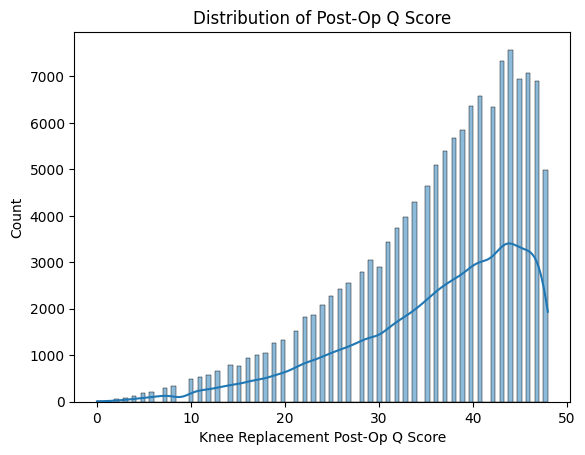

In [ ]:
df[outcome].describe()

sns.histplot(df[outcome], kde=True)
plt.title("Distribution of Post-Op Q Score")
plt.show()

<Axes: xlabel='Knee Replacement Pre-Op Q Score', ylabel='Knee Replacement Post-Op Q Score'>

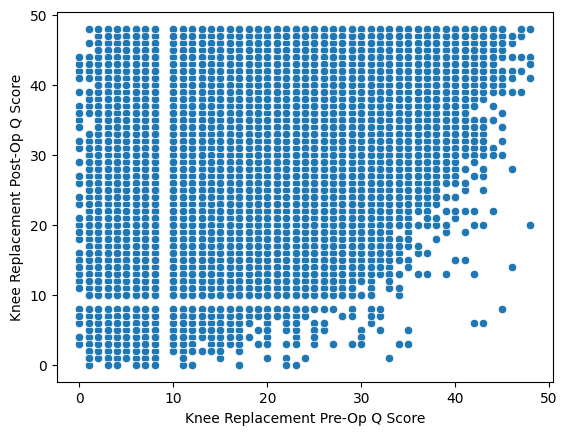

In [ ]:
sns.scatterplot(
    x = df["Knee Replacement Pre-Op Q Score"],
    y = df[outcome]
)

In [ ]:
cols = [
    "Knee Replacement Pre-Op Q Score",
    "Knee Replacement Post-Op Q Score"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[cols].dtypes

df_corr = df[cols].dropna()
df_corr.corr()

,Knee Replacement Pre-Op Q Score,Knee Replacement Post-Op Q Score
Knee Replacement Pre-Op Q Score,1.000000,0.350294
Knee Replacement Post-Op Q Score,0.350294,1.000000


In [ ]:
num_df = df.select_dtypes(include='number')

corr_with_outcome = (
    num_df.corr()[outcome]
    .drop([outcome, "Knee Replacement OKS Post-Op Q Predicted", "Knee Replacement EQ VAS_Post-Op Q Predicted", "Knee Replacement Pre-Op Q Score", "Pre-Op Q EQ5D Index", "Pre-Op Q EQ5D Index Profile", "Revision Flag"])
    .sort_values(ascending=False)
)
#"Pre-Op Q EQ VAS""Post-Op Q EQ VAS"
print(corr_with_outcome)

Knee Replacement Pre-Op Q Shopping      0.310815
Knee Replacement Pre-Op Q Washing       0.291441
Knee Replacement Pre-Op Q Stairs        0.275023
Knee Replacement Pre-Op Q Transport     0.266891
Knee Replacement Pre-Op Q Work          0.265263
Pre-Op Q Disability                     0.249594
Knee Replacement Pre-Op Q Kneeling      0.244770
Knee Replacement Pre-Op Q Confidence    0.242692
Knee Replacement Pre-Op Q Standing      0.230170
Knee Replacement Pre-Op Q Night Pain    0.221905
Knee Replacement Pre-Op Q Walking       0.199085
Knee Replacement Pre-Op Q Pain          0.160686
Knee Replacement Pre-Op Q Limping       0.108114
Post-Op Q EQ VAS                        0.001060
Cancer                                 -0.000645
Pre-Op Q Symptom Period                -0.010949
Pre-Op Q EQ VAS                        -0.017032
Liver Disease                          -0.024019
Kidney Disease                         -0.031354
Nervous System                         -0.034309
High Bp             

In [ ]:
item_cols = corr_with_outcome.index.tolist()

corr_items = df[item_cols].corr().abs()

high_pairs = (
    corr_items.where(np.triu(np.ones(corr_items.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_pairs.head(15)

Knee Replacement Pre-Op Q Shopping   Knee Replacement Pre-Op Q Stairs        0.595983
Knee Replacement Pre-Op Q Pain       Pre-Op Q Discomfort                     0.574668
Knee Replacement Pre-Op Q Shopping   Knee Replacement Pre-Op Q Work          0.573024
Knee Replacement Pre-Op Q Washing    Pre-Op Q Self-Care                      0.552718
                                     Knee Replacement Pre-Op Q Transport     0.523674
Knee Replacement Pre-Op Q Stairs     Knee Replacement Pre-Op Q Work          0.522175
Knee Replacement Pre-Op Q Work       Knee Replacement Pre-Op Q Standing      0.519637
Knee Replacement Pre-Op Q Stairs     Knee Replacement Pre-Op Q Transport     0.513368
Knee Replacement Pre-Op Q Work       Pre-Op Q Discomfort                     0.502530
Knee Replacement Pre-Op Q Shopping   Knee Replacement Pre-Op Q Transport     0.499293
Knee Replacement Pre-Op Q Transport  Knee Replacement Pre-Op Q Standing      0.493692
Knee Replacement Pre-Op Q Work       Knee Replacement 

In [ ]:
# Demografical analyses

print(df["Gender"].value_counts(normalize=True))

print("")

print(df["Age Band"].value_counts(normalize=True))

print("")

print(df["Pre-Op Q Living Arrangements"].value_counts(normalize=True))

print("")

print(df["Pre-Op Q Previous Surgery"].value_counts(normalize=True))

Gender
Female    0.570613
Male      0.429387
Name: proportion, dtype: float64

Age Band
70 to 79     0.424049
60 to 69     0.349377
80 to 89     0.122333
50 to 59     0.102130
40 to 49     0.001926
90 to 120    0.000185
Name: proportion, dtype: float64

Pre-Op Q Living Arrangements
Living with partner/spouse/family/friends                          0.773181
Alone                                                              0.222306
Other                                                              0.003544
Living in a nursing home, hospital or other long-term care home    0.000970
Name: proportion, dtype: float64

Pre-Op Q Previous Surgery
0.0    0.921965
1.0    0.078035
Name: proportion, dtype: float64


In [ ]:
# Base line statistics

print(df["Knee Replacement EQ VAS_Post-Op Q Predicted"].describe())

print("")

print(df["Pre-Op Q EQ5D Index"].describe())

print("")

print(df["Knee Replacement Pre-Op Q Score"].describe())

count    119813.000000
mean         72.584332
std           9.464312
min          21.761826
25%          65.962373
50%          73.172938
75%          79.811137
max          93.985650
Name: Knee Replacement EQ VAS_Post-Op Q Predicted, dtype: float64

count    131736.000000
mean          0.412106
std           0.312587
min          -0.594000
25%           0.088000
50%           0.587000
75%           0.691000
max           1.000000
Name: Pre-Op Q EQ5D Index, dtype: float64

count    133719.000000
mean         19.269438
std           7.669271
min           0.000000
25%          14.000000
50%          19.000000
75%          24.000000
max          48.000000
Name: Knee Replacement Pre-Op Q Score, dtype: float64


In [ ]:
# Comorbidity prevalence

df[columns_to_fix_9_value].mean()

Cancer            0.054174
Circulation       0.056609
Depression        0.093589
Diabetes          0.124817
Arthritis         0.770447
Heart Disease     0.093733
High Bp           0.442199
Kidney Disease    0.020512
Lung Disease      0.091779
Liver Disease     0.005832
Nervous System    0.010213
Stroke            0.016540
dtype: float64

In [ ]:
df.groupby("Gender")[outcome].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,72369.0,35.139341,9.419631,0.0,29.0,37.0,43.0,48.0
Male,54710.0,37.129446,9.123780,0.0,32.0,40.0,44.0,48.0


In [ ]:
df.groupby("Age Band")[outcome].describe()

,count,mean,std,min,25%,50%,75%,max
Age Band,,,,,,,,
40 to 49,244.0,33.127049,11.720170,3.0,27.0,36.0,43.0,48.0
50 to 59,13028.0,34.166027,10.442699,0.0,28.0,37.0,43.0,48.0
60 to 69,44532.0,36.020165,9.486374,0.0,31.0,38.0,44.0,48.0
70 to 79,53875.0,36.602265,8.927107,0.0,31.0,39.0,44.0,48.0
80 to 89,15377.0,35.404630,9.092907,0.0,30.0,37.0,43.0,48.0
90 to 120,23.0,32.130435,8.181489,14.0,26.5,36.0,38.0,43.0


In [ ]:
df.groupby("Pre-Op Q Living Arrangements")[outcome].describe()

,count,mean,std,min,25%,50%,75%,max
Pre-Op Q Living Arrangements,,,,,,,,
Alone,29702.0,35.215474,9.518050,0.0,29.0,37.0,43.0,48.0
"Living in a nursing home, hospital or other long-term care home",120.0,30.816667,9.303459,2.0,25.0,31.0,39.0,47.0
Living with partner/spouse/family/friends,103955.0,36.213092,9.311250,0.0,31.0,38.0,44.0,48.0
Other,469.0,33.462687,10.098299,4.0,27.0,35.0,41.0,48.0


In [ ]:
df.groupby(["Gender", "Age Band"])[outcome].describe()

count       mean        std   min    25%   50%   75%   max
Gender Age Band                                                               
Female 40 to 49     187.0  32.572193  11.891936   3.0  26.00  35.0  42.5  48.0
       50 to 59    8380.0  33.402864  10.436687   0.0  27.00  36.0  42.0  48.0
       60 to 69   24333.0  35.229565   9.519592   0.0  29.00  37.0  43.0  48.0
       70 to 79   30064.0  35.755655   9.028823   0.0  30.00  38.0  43.0  48.0
       80 to 89    9387.0  34.538830   9.137808   0.0  29.00  36.0  42.0  48.0
       90 to 120     18.0  32.055556   7.802505  15.0  26.25  33.5  38.0  43.0
Male   40 to 49      57.0  34.947368  11.042808   6.0  31.00  38.0  43.0  48.0
       50 to 59    4648.0  35.541954  10.312899   1.0  29.00  39.0  44.0  48.0
       60 to 69   20199.0  36.972573   9.358154   2.0  32.00  40.0  44.0  48.0
       70 to 79   23811.0  37.671202   8.680025   0.0  33.00  40.0  44.0  48.0
       80 to 89    5990.0  36.761436   8.854137   1.0  31.00  39.0  44.0  48.0
       90 to 120      5.0  32.400000  10.454664  14.0  34.00  37.0  38.0  39.0

In [ ]:
df.groupby(["Age Band", "Pre-Op Q Living Arrangements"])[outcome].describe()

count  \
Age Band  Pre-Op Q Living Arrangements                                  
40 to 49  Alone                                                  31.0   
          Living in a nursing home, hospital or other lon...      1.0   
          Living with partner/spouse/family/friends             210.0   
          Other                                                   1.0   
50 to 59  Alone                                                1645.0   
          Living in a nursing home, hospital or other lon...     11.0   
          Living with partner/spouse/family/friends           11232.0   
          Other                                                  53.0   
60 to 69  Alone                                                7001.0   
          Living in a nursing home, hospital or other lon...     25.0   
          Living with partner/spouse/family/friends           36924.0   
          Other                                                 111.0   
70 to 79  Alone                                               12656.0   
          Living in a nursing home, hospital or other lon...     34.0   
          Living with partner/spouse/family/friends           40038.0   
          Other                                                 169.0   
80 to 89  Alone                                                6485.0   
          Living in a nursing home, hospital or other lon...     35.0   
          Living with partner/spouse/family/friends            8388.0   
          Other                                                  90.0   
90 to 120 Alone                                                  16.0   
          Living with partner/spouse/family/friends               7.0   

                                                                   mean  \
Age Band  Pre-Op Q Living Arrangements                                    
40 to 49  Alone                                               31.354839   
          Living in a nursing home, hospital or other lon...  28.000000   
          Living with partner/spouse/family/friends           33.323810   
          Other                                               42.000000   
50 to 59  Alone                                               32.018237   
          Living in a nursing home, hospital or other lon...  26.909091   
          Living with partner/spouse/family/friends           34.517539   
          Other                                               31.094340   
60 to 69  Alone                                               35.078703   
          Living in a nursing home, hospital or other lon...  32.640000   
          Living with partner/spouse/family/friends           36.225626   
          Other                                               33.396396   
70 to 79  Alone                                               35.880215   
          Living in a nursing home, hospital or other lon...  32.323529   
          Living with partner/spouse/family/friends           36.856911   
          Other                                               34.420118   
80 to 89  Alone                                               35.062606   
          Living in a nursing home, hospital or other lon...  30.228571   
          Living with partner/spouse/family/friends           35.758345   
          Other                                               33.233333   
90 to 120 Alone                                               32.750000   
          Living with partner/spouse/family/friends           30.714286   

                                                                    std   min  \
Age Band  Pre-Op Q Living Arrangements                                          
40 to 49  Alone                                               12.308665   6.0   
          Living in a nursing home, hospital or other lon...        NaN  28.0   
          Living with partner/spouse/family/friends           11.682806   3.0   
          Other                                                     NaN  42.0   
50 to 59  Alone         

In [ ]:
df.groupby(["Pre-Op Q Living Arrangements", "Age Band"])[outcome].describe()

count  \
Pre-Op Q Living Arrangements                       Age Band             
Alone                                              40 to 49      31.0   
                                                   50 to 59    1645.0   
                                                   60 to 69    7001.0   
                                                   70 to 79   12656.0   
                                                   80 to 89    6485.0   
                                                   90 to 120     16.0   
Living in a nursing home, hospital or other lon... 40 to 49       1.0   
                                                   50 to 59      11.0   
                                                   60 to 69      25.0   
                                                   70 to 79      34.0   
                                                   80 to 89      35.0   
Living with partner/spouse/family/friends          40 to 49     210.0   
                                                   50 to 59   11232.0   
                                                   60 to 69   36924.0   
                                                   70 to 79   40038.0   
                                                   80 to 89    8388.0   
                                                   90 to 120      7.0   
Other                                              40 to 49       1.0   
                                                   50 to 59      53.0   
                                                   60 to 69     111.0   
                                                   70 to 79     169.0   
                                                   80 to 89      90.0   

                                                                   mean  \
Pre-Op Q Living Arrangements                       Age Band               
Alone                                              40 to 49   31.354839   
                                                   50 to 59   32.018237   
                                                   60 to 69   35.078703   
                                                   70 to 79   35.880215   
                                                   80 to 89   35.062606   
                                                   90 to 120  32.750000   
Living in a nursing home, hospital or other lon... 40 to 49   28.000000   
                                                   50 to 59   26.909091   
                                                   60 to 69   32.640000   
                                                   70 to 79   32.323529   
                                                   80 to 89   30.228571   
Living with partner/spouse/family/friends          40 to 49   33.323810   
                                                   50 to 59   34.517539   
                                                   60 to 69   36.225626   
                                                   70 to 79   36.856911   
                                                   80 to 89   35.758345   
                                                   90 to 120  30.714286   
Other                                              40 to 49   42.000000   
                                                   50 to 59   31.094340   
                                                   60 to 69   33.396396   
                                                   70 to 79   34.420118   
                                                   80 to 89   33.233333   

                                                                    std   min  \
Pre-Op Q Living Arrangements                       Age Band                     
Alone                                              40 to 49   12.308665   6.0   
                                                   50 to 59   11.325408   1.0   
                                                   60 to 69    9.877519   0.0   
                                                   70 to 79    9.128428   0.0   
                        

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].value_counts(normalize=True).head())


 Provider Code
Provider Code
RL1      0.022516
RVR      0.020749
RRF      0.018242
NXM01    0.015420
RTF      0.015262
Name: proportion, dtype: float64

 Year
Year
2016/17    0.341894
2017/18    0.330353
2018/19    0.327753
Name: proportion, dtype: float64

 Age Band
Age Band
70 to 79    0.424049
60 to 69    0.349377
80 to 89    0.122333
50 to 59    0.102130
40 to 49    0.001926
Name: proportion, dtype: float64

 Gender
Gender
Female    0.570613
Male      0.429387
Name: proportion, dtype: float64

 Pre-Op Q Living Arrangements
Pre-Op Q Living Arrangements
Living with partner/spouse/family/friends                          0.773181
Alone                                                              0.222306
Other                                                              0.003544
Living in a nursing home, hospital or other long-term care home    0.000970
Name: proportion, dtype: float64


In [ ]:
df["Age Band Missing"] = df["Age Band"].isna()
df.groupby("Age Band Missing")[outcome].mean()

Age Band Missing
False    35.996121
True     35.546917
Name: Knee Replacement Post-Op Q Score, dtype: float64

In [ ]:
df["Gender Missing"] = df["Gender"].isna()
df.groupby("Gender Missing")[outcome].mean()

Gender Missing
False    35.996121
True     35.546917
Name: Knee Replacement Post-Op Q Score, dtype: float64

In [ ]:
# Replace values (for consistancy)

#col = "Pre-Op Q Assisted"

#df_Tbl_Knee_Replacement_Provider_cleaned[col] = (
#    pd.to_numeric(df_Tbl_Knee_Replacement_Provider_cleaned[col], errors="coerce")
#      .replace({1: 1, 2: 0})
#      .astype("Int64")   # keeps <NA> (pandas nullable int)
#)

#df_Tbl_Knee_Replacement_Provider_cleaned["Pre-Op Q Assisted"].unique()

#df_Tbl_Knee_Replacement_Provider_cleaned["Pre-Op Q Assisted"] = (
#    pd.to_numeric(df_Tbl_Knee_Replacement_Provider_cleaned["Pre-Op Q Assisted"], errors="coerce")
#      .replace({1: 1, 2: 0})
#      .astype("Int64")
#)

#df_Tbl_Knee_Replacement_Provider_cleaned["Pre-Op Q Disability"] = (
#    pd.to_numeric(df_Tbl_Knee_Replacement_Provider_cleaned["Pre-Op Q Disability"], errors="coerce")
#      .replace({1: 1, 2: 0})
#      .astype("Int64")
#)

#print(df_Tbl_Knee_Replacement_Provider_cleaned["Pre-Op Q Assisted"].value_counts(dropna=False))
#print(df_Tbl_Knee_Replacement_Provider_cleaned["Pre-Op Q Disability"].value_counts(dropna=False))


In [ ]:
# Create dummy variables

#df_Tbl_Knee_Replacement_Provider_cleaned_with_dummies = pd.get_dummies(
#    df_Tbl_Knee_Replacement_Provider_cleaned,
#    columns= ["Gender", "Age Band", "Pre-Op Q Assisted By", "Pre-Op Q Living Arrangements"], 
#    drop_first=True
#)

#df_Tbl_Knee_Replacement_Provider_cleaned_with_dummies["Pre-Op Q Living Arrangements_2"].value_counts()